# 🏗️ Concrete Compressive Strength — Gradient Boosting Regression

**🇹🇷 Türkçe:**
Bu notebook, **UCI Concrete Compressive Strength** veri seti üzerinde betonun basınç dayanımını (`Strength`, MPa) tahmin eden bir **Gradient Boosting** regresyon modeli kuruyor. Veri seti 1030 beton karışımına ait 8 girdi değişkeni içeriyor: karışıma giren malzeme miktarları (kg/m³) ve kürlenme yaşı (gün).

**Gradient Boosting** bir *boosting* yöntemidir: ağaçları Random Forest gibi paralel değil, **sırayla** kurar. Ancak AdaBoost'tan önemli bir farkı vardır — AdaBoost yanlış tahmin edilen örneklerin **ağırlığını** artırırken, Gradient Boosting her yeni ağacı bir öncekinin **artıklarına (residual)** yani hatalarına uydurur. Her ağaç "önceki modelin ne kadar yanıldığını" öğrenir ve tahmin, `learning_rate` ile ölçeklenerek toplama eklenir.

Notebook; keşifsel veri analizi, ön işleme, temel model kurulumu, özellik önemi analizi ve `GridSearchCV` ile hiperparametre optimizasyonunu kapsıyor.

**🇬🇧 English:**
This notebook builds a **Gradient Boosting** regression model to predict concrete compressive strength (`Strength`, in MPa) on the **UCI Concrete Compressive Strength** dataset. It contains 1,030 concrete mixtures described by 8 input variables: the quantity of each ingredient (kg/m³) and the curing age (days).

**Gradient Boosting** is a *boosting* method: it builds trees **sequentially** rather than in parallel like Random Forest. Its key difference from AdaBoost is that instead of re-weighting misclassified samples, each new tree is fit to the **residuals** of the current ensemble — every tree learns "how wrong the previous model was", and its prediction is scaled by `learning_rate` before being added to the sum.

The notebook covers exploratory analysis, preprocessing, a baseline model, feature-importance analysis, and hyperparameter tuning with `GridSearchCV`.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme, sayısal hesaplama ve görselleştirme için gereken temel kütüphaneler tek hücrede toplanıyor. Scikit-learn bileşenleri ilgili adımların hemen öncesinde import ediliyor.

**🇬🇧 English:**
The core libraries for data handling, numeric computation, and visualization are collected in a single cell. Scikit-learn components are imported just before the step that uses them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Veri seti CSV dosyasından okunuyor. Hedef değişken `Strength` — betonun basınç dayanımı (MPa). İlk yedi kolonun birimi **kg/m³**, yani bir metreküp beton karışımına giren malzeme miktarı; `Age` ise **gün** cinsindendir.

| Kolon | Anlamı / Meaning |
|---|---|
| `Cement` | Çimento — bağlayıcı ana madde / Cement, the primary binder |
| `Blast Furnace Slag` | Yüksek fırın cürufu — kısmi çimento ikamesi / Ground slag, a partial cement replacement |
| `Fly Ash` | Uçucu kül — kısmi çimento ikamesi / Fly ash, a partial cement replacement |
| `Water` | Su — hidratasyonu sağlar / Water, drives hydration |
| `Superplasticizer` | Süperakışkanlaştırıcı katkı / Superplasticizer admixture |
| `Coarse Aggregate` | İri agrega (çakıl) / Coarse aggregate (gravel) |
| `Fine Aggregate` | İnce agrega (kum) / Fine aggregate (sand) |
| `Age` | Kürlenme yaşı, gün / Curing age, in days |
| `Strength` | **Hedef:** basınç dayanımı, MPa / **Target:** compressive strength, in MPa |

**🇬🇧 English:**
The dataset is read from CSV. The target is `Strength`, the compressive strength in MPa. The first seven columns are measured in **kg/m³** (the amount of each ingredient per cubic metre of mixture), while `Age` is measured in **days**.

In [2]:
df = pd.read_csv("../../Data/18-concrete_data.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()`, `info()`, `isnull().sum()` ve `describe()` ile veri setinin yapısı inceleniyor: 1030 satır, 9 kolon, hepsi sayısal ve **hiç eksik değer yok**. `describe()` çıktısı ayrıca `Blast Furnace Slag`, `Fly Ash` ve `Superplasticizer` kolonlarının minimumunun 0 olduğunu gösteriyor — bunlar eksik değer değil, gerçek bilgidir: bu malzemeler **isteğe bağlı katkılardır** ve birçok karışımda hiç kullanılmamıştır.

**🇬🇧 English:**
`head()`, `info()`, `isnull().sum()` and `describe()` outline the dataset: 1,030 rows, 9 columns, all numeric, with **no missing values**. `describe()` also shows a minimum of 0 for `Blast Furnace Slag`, `Fly Ash` and `Superplasticizer` — these are not missing values but genuine information: those ingredients are **optional admixtures** and simply absent from many mixtures.

In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [5]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [6]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## 📊 3. Keşifsel Veri Analizi / Exploratory Data Analysis

### 3.1 Dağılımlar ve Aykırı Değerler / Distributions and Outliers

**🇹🇷 Türkçe:**
Her kolon için histogram ve kutu grafiği çiziliyor. Dikkat çeken noktalar: `Age` şiddetli sağa çarpık (numunelerin büyük kısmı 28 günlük), `Blast Furnace Slag` ve `Fly Ash` sıfırda yoğunlaşıyor, `Superplasticizer` ise sıfır ile 32 arasında geniş bir kuyruk gösteriyor.

**🇬🇧 English:**
A histogram and a box plot are drawn for every column. Notable patterns: `Age` is heavily right-skewed (most specimens are tested at 28 days), `Blast Furnace Slag` and `Fly Ash` pile up at zero, and `Superplasticizer` shows a long tail out to 32.

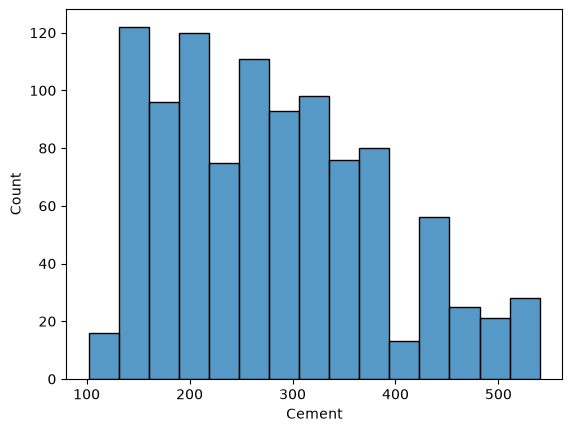

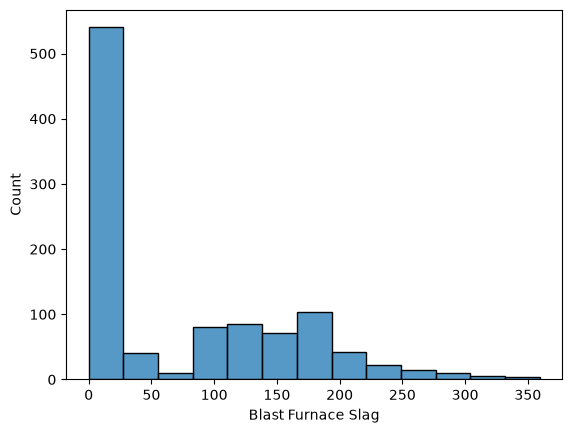

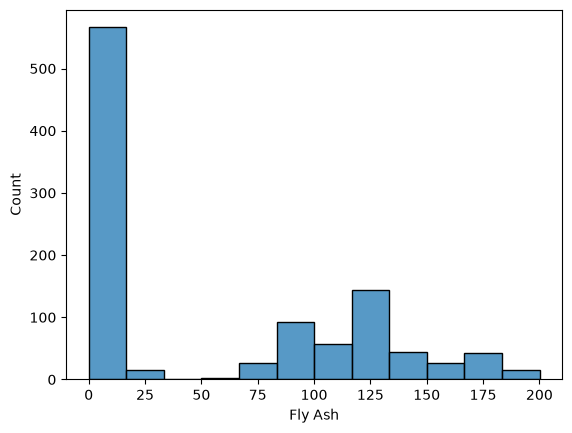

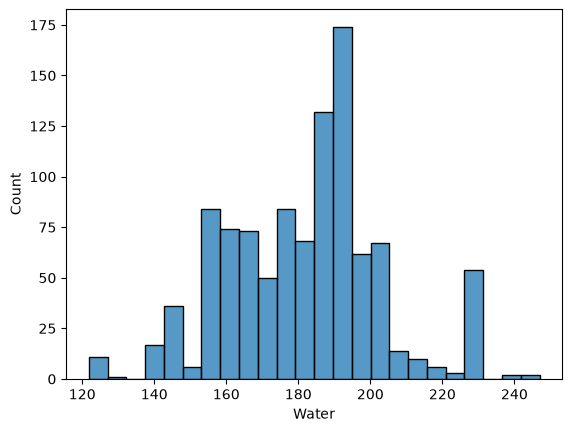

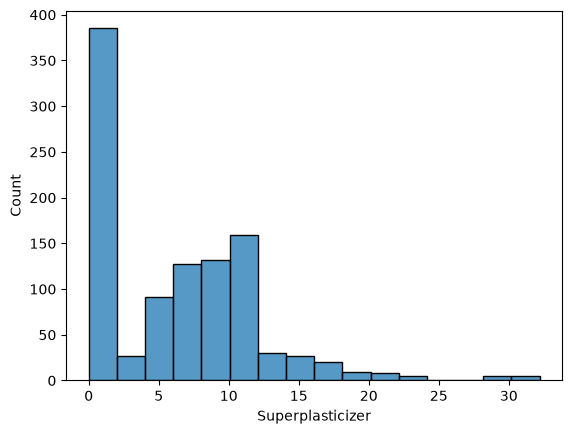

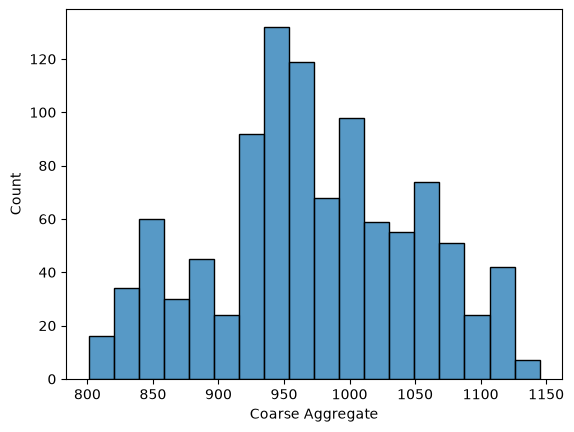

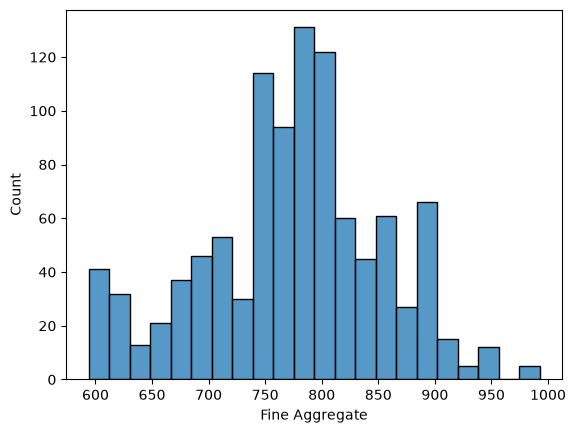

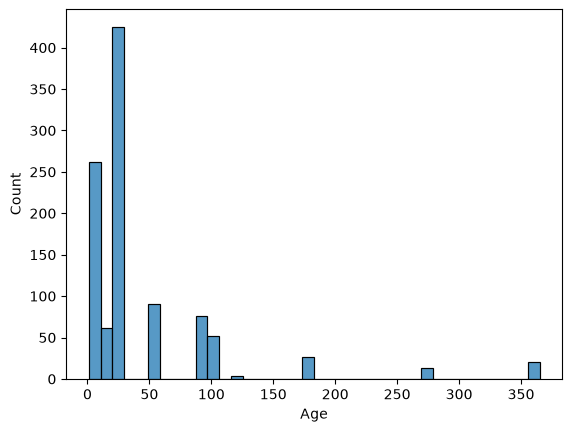

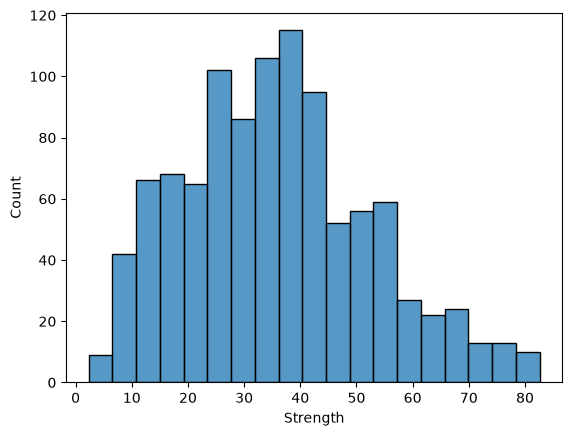

In [7]:
for i in df.columns:
    sns.histplot(df[i])
    plt.show()

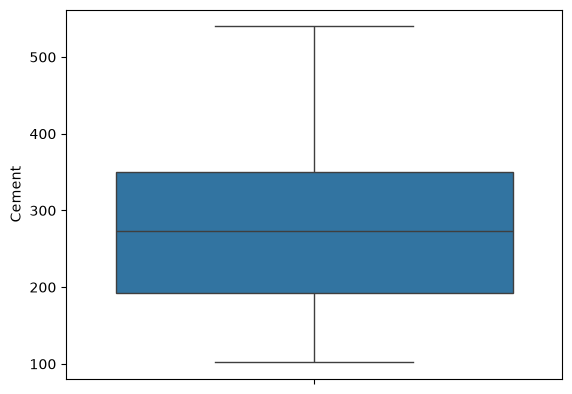

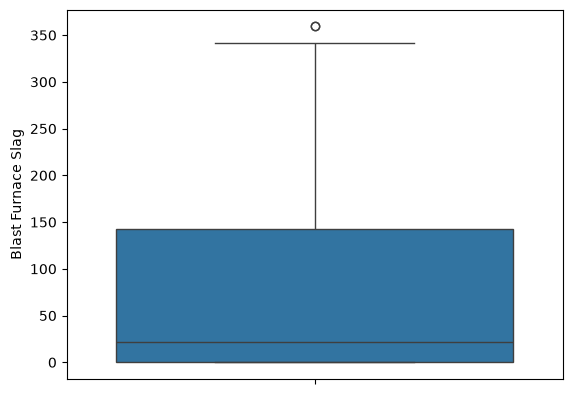

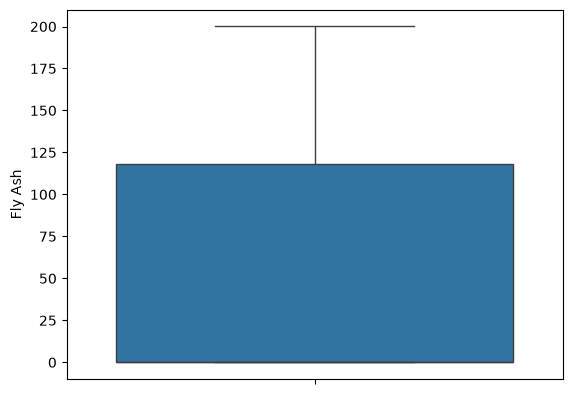

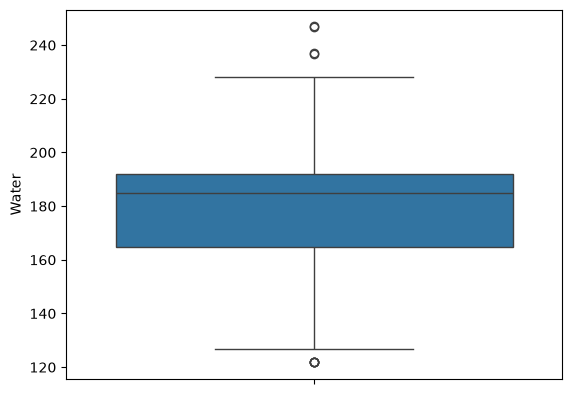

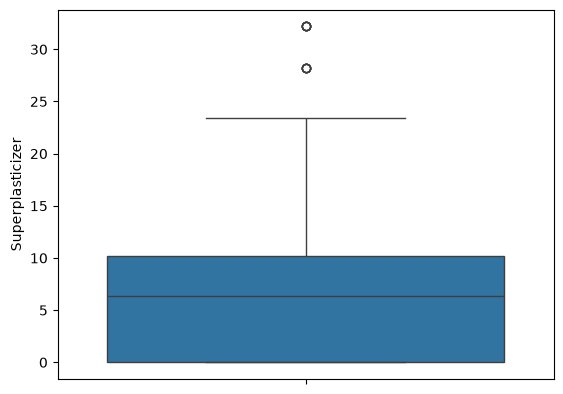

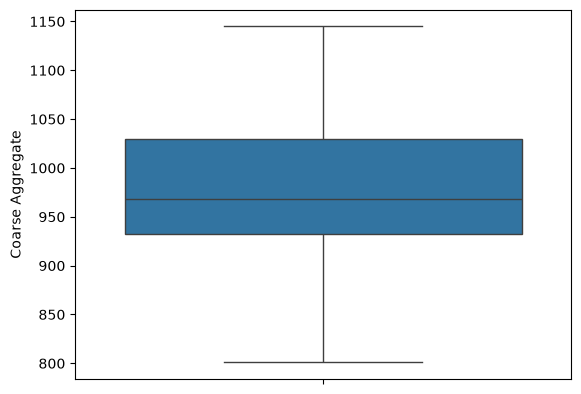

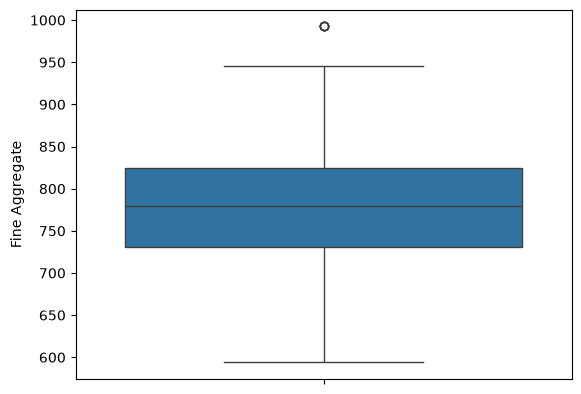

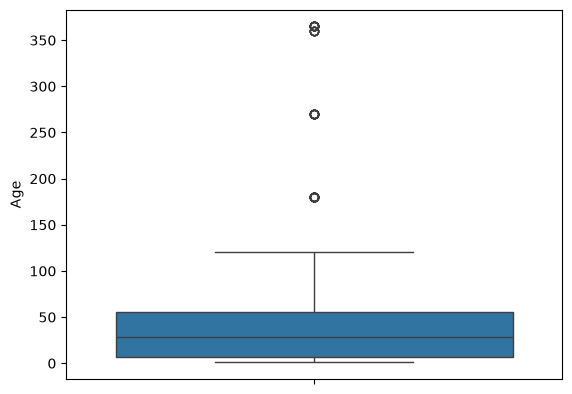

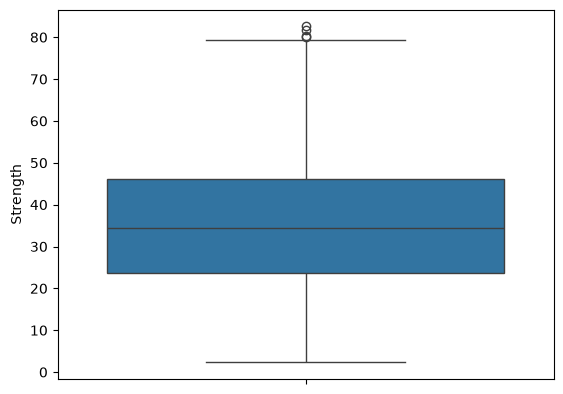

In [8]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

### 3.2 Özellik–Hedef İlişkileri / Feature vs. Target Scatter Plots

**🇹🇷 Türkçe:**
Her özellik `Strength`'e karşı çiziliyor. Bu grafikler **marjinal** ilişkiyi gösterir: diğer 7 değişken kontrol edilmeden bakılır. Bu yüzden zayıf görünen bir ilişki, değişkenin önemsiz olduğu anlamına gelmez.

Somut bir örnek: `Blast Furnace Slag` grafiğinde dayanımın cüruftan pek etkilenmediği izlenimi doğar. Ancak cüruf, çimentonun *yerine* konan bir malzemedir (`corr(Slag, Cement) = -0.275`); cüruf artarken çimento azaldığı için iki etki grafikte birbirini götürür. Yaş ve çimento sabitlendiğinde cüruf içeren karışımların ortalama dayanımı belirgin biçimde daha yüksektir.

**🇬🇧 English:**
Each feature is plotted against `Strength`. These plots show the **marginal** relationship — the other seven variables are left uncontrolled — so a relationship that looks weak here does not mean the variable is unimportant.

A concrete example: the `Blast Furnace Slag` panel suggests strength barely responds to slag. But slag is a *substitute* for cement (`corr(Slag, Cement) = -0.275`), so as slag rises cement falls and the two effects cancel out in the plot. Once age and cement are held fixed, mixtures containing slag are clearly stronger on average.

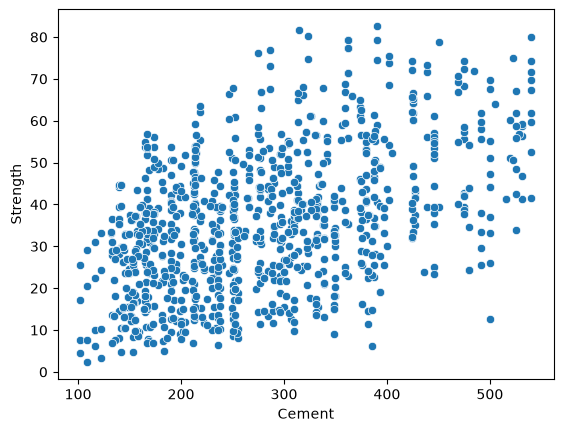

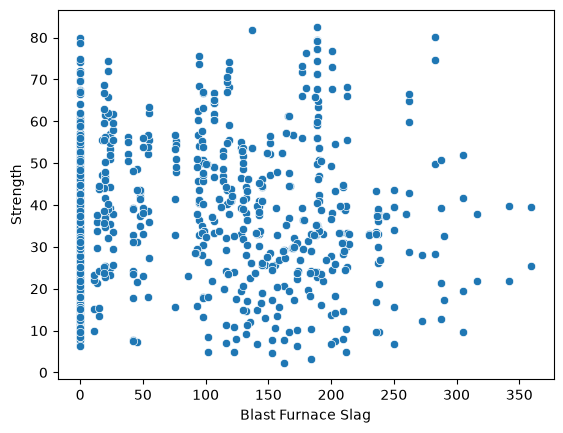

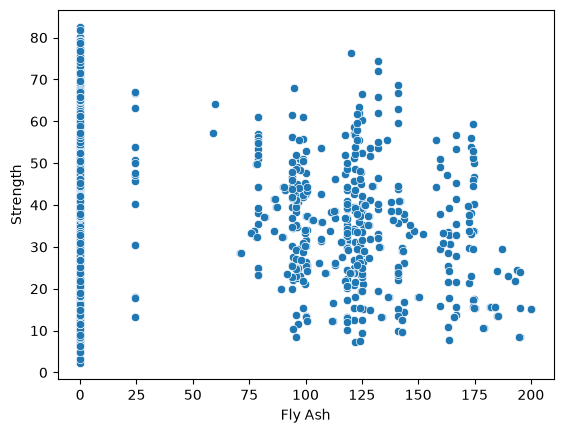

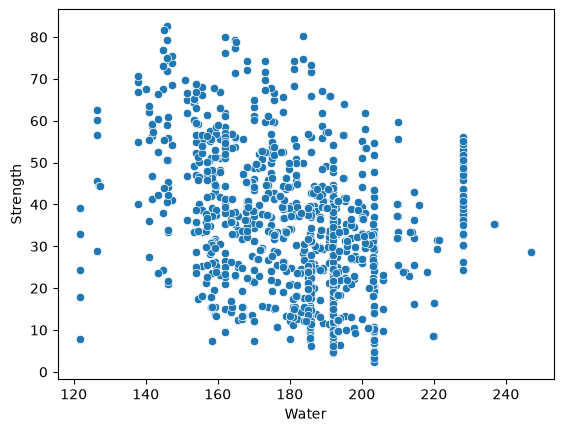

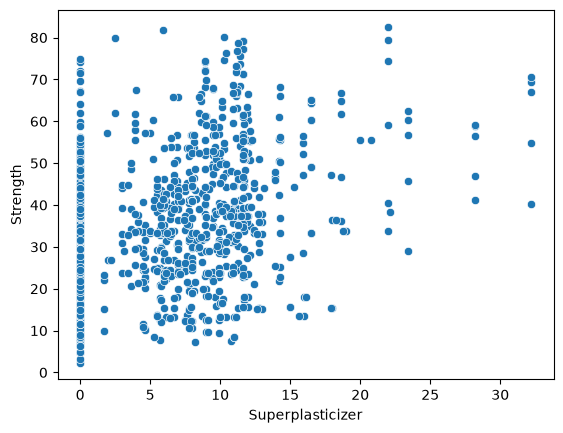

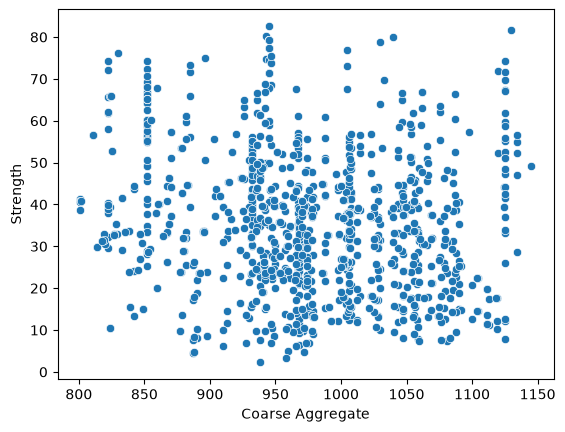

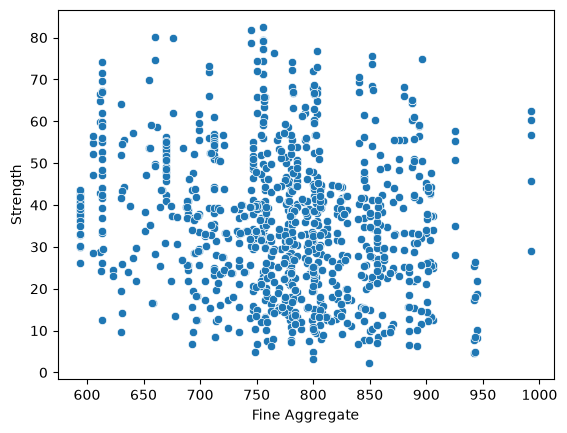

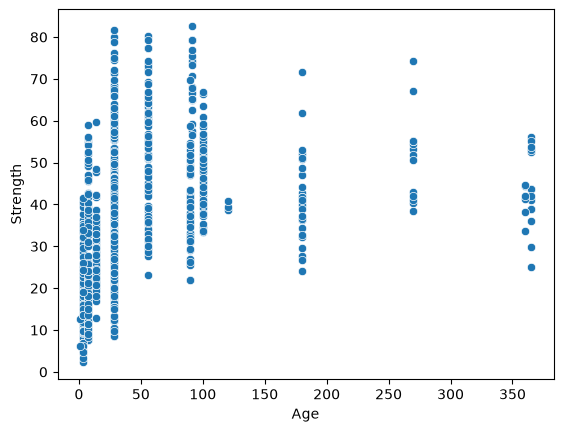

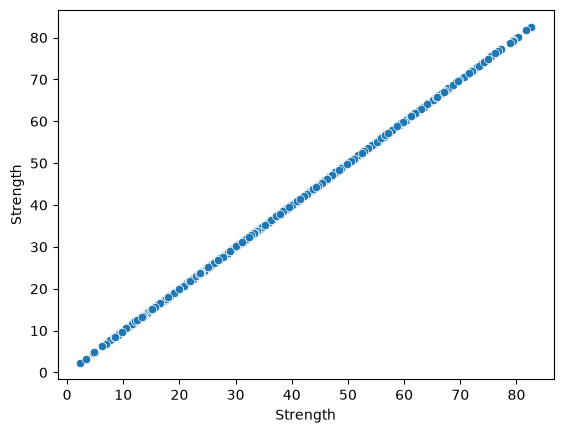

In [9]:
for i in df.columns:
    sns.scatterplot(x=df[i], y=df["Strength"])
    plt.show()

### 3.3 Korelasyon Isı Haritası / Correlation Heatmap

**🇹🇷 Türkçe:**
Isı haritası **Pearson** korelasyonunu gösterir ve Pearson yalnızca **doğrusal** ilişkiyi ölçer. Bu, ilerideki özellik önemi sonuçlarını okurken kritik bir ayrımdır.

`Age` iyi bir örnektir: Pearson korelasyonu yalnızca **0.329** iken `Cement` için **0.498**'dir. Ancak yaş–dayanım ilişkisi doğrusal değil, **logaritmiktir** (ilk 28 günde +27 MPa, sonraki 337 günde yalnızca +7 MPa). Sıra bazlı **Spearman** korelasyonuna bakıldığında sıralama tersine döner: `Age` 0.596, `Cement` 0.478. Ağaç tabanlı modeller eşik bölmesi yaptıkları için doğrusallık aramaz; bu nedenle `Age`'den Pearson'ın gördüğünden çok daha fazla bilgi çıkarırlar.

**Kural:** Pearson'ı düşük ama Spearman'ı yüksek olan bir değişken, doğrusal olmayan ama monoton bir ilişkiye işaret eder.

**🇬🇧 English:**
The heatmap reports **Pearson** correlation, which measures only the **linear** part of a relationship — a distinction that matters when reading the feature importances later.

`Age` illustrates this: its Pearson correlation with the target is just **0.329** versus **0.498** for `Cement`. But the age–strength relationship is **logarithmic**, not linear (+27 MPa over the first 28 days, only +7 MPa over the following 337). Switching to rank-based **Spearman** correlation reverses the ranking: `Age` 0.596, `Cement` 0.478. Tree-based models split on thresholds and never assume linearity, so they extract far more from `Age` than Pearson suggests.

**Rule of thumb:** a low Pearson with a high Spearman signals a non-linear but monotonic relationship.

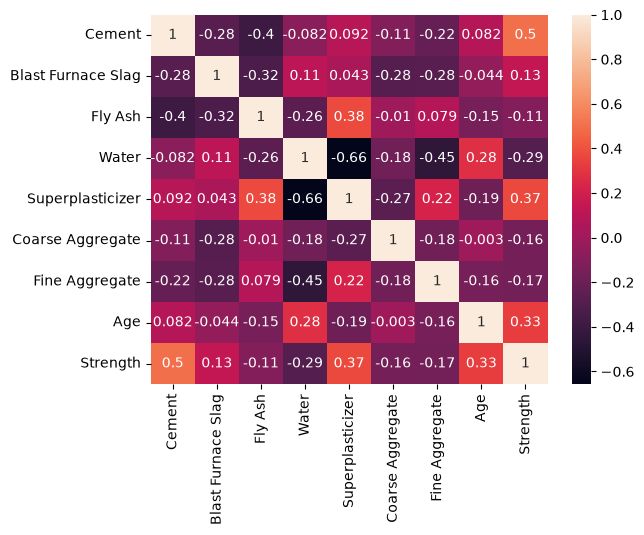

In [10]:
sns.heatmap(df.corr(), annot=True)
plt.show()

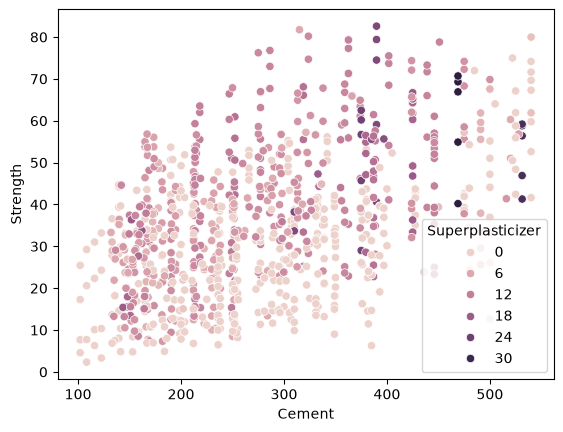

In [11]:
sns.scatterplot(x=df["Cement"], y=df["Strength"], hue=df["Superplasticizer"])
plt.show()

## 🎯 4. Özellik ve Hedef Ayrımı / Feature–Target Split

**🇹🇷 Türkçe:**
`Strength` hedef değişken olarak ayrılıyor, kalan 8 kolon özellik matrisi `X`'i oluşturuyor.

**🇬🇧 English:**
`Strength` is separated as the target, and the remaining 8 columns form the feature matrix `X`.

In [12]:
X = df.drop("Strength", axis=1)
y = df["Strength"]

## ⚙️ 5. Ön İşleme / Preprocessing

**🇹🇷 Türkçe:**
Tüm sayısal kolonlar `StandardScaler` ile ölçekleniyor; ölçekleyici bir `Pipeline` içine, o da bir `ColumnTransformer` içine yerleştiriliyor.

**Not — bu adım Gradient Boosting için gerekli değildir.** Ağaç tabanlı modeller eşik karşılaştırması yapar (`Age < 14?`), dolayısıyla değişkenlerin ölçeğine tamamen duyarsızdır; ölçekli ve ölçeksiz sonuçlar aynı çıkar. Adım burada boru hattı disiplinini korumak ve KNN/SVM gibi mesafe tabanlı modellerle karşılaştırılabilir bir yapı kurmak için bilinçli olarak bırakılmıştır.

**🇬🇧 English:**
All numeric columns are standardized with `StandardScaler`, wrapped in a `Pipeline` and then in a `ColumnTransformer`.

**Note — this step is not required for Gradient Boosting.** Tree-based models compare thresholds (`Age < 14?`) and are therefore completely invariant to feature scale; the scaled and unscaled results are identical. The step is kept deliberately, to preserve pipeline discipline and to keep the structure comparable with the distance-based models (KNN, SVM) elsewhere in this repository.

In [13]:
scaler_cols = X.columns.tolist()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [15]:
scaler_pipe = Pipeline([("scaler", StandardScaler())])
preprocessor_pipe = ColumnTransformer([("preprocessor", scaler_pipe, scaler_cols)])

## ✂️ 6. Train/Test Ayrımı ve Sızıntı Disiplini / Train-Test Split and Leakage Discipline

**🇹🇷 Türkçe:**
Veri %80 eğitim / %20 test olarak bölünüyor. **Sıralama kritiktir:** ölçekleyici yalnızca eğitim kümesine `fit_transform` ile uygulanıyor, test kümesine ise sadece `transform` uygulanıyor. Böylece test kümesinin ortalama ve standart sapması modele hiçbir şekilde sızmıyor.

**🇬🇧 English:**
The data is split 80/20 into training and test sets. **Order matters:** the scaler is `fit_transform`ed on the training set only and merely `transform`ed on the test set, so the test set's mean and standard deviation never leak into the model.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train_sca = preprocessor_pipe.fit_transform(X_train)
X_test_sca = preprocessor_pipe.transform(X_test)

## 🌲 7. Gradient Boosting Modeli / The Gradient Boosting Model

**🇹🇷 Türkçe:**
`GradientBoostingRegressor` varsayılan parametrelerle kuruluyor (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`).

Algoritmanın çalışma mantığı:
1. Basit bir tahminle başla (hedefin ortalaması).
2. Mevcut modelin **artıklarını** (gerçek − tahmin) hesapla.
3. Bu artıkları tahmin eden **sığ** bir ağaç eğit.
4. Ağacın çıktısını `learning_rate` ile çarparak toplama ekle.
5. `n_estimators` kez tekrarla.

Buradaki ağaçlar bilinçli olarak **zayıftır** (`max_depth=3`). Boosting'in fikri, çok sayıda zayıf öğreniciyi üst üste koymaktır; derin ağaçlar kullanılırsa ilk ağaç veriyi zaten ezberler ve sonrakilere düzeltecek hata kalmaz.

**🇬🇧 English:**
A `GradientBoostingRegressor` is fitted with default parameters (`n_estimators=100`, `learning_rate=0.1`, `max_depth=3`).

How the algorithm works:
1. Start from a naive prediction (the mean of the target).
2. Compute the **residuals** of the current model (actual − predicted).
3. Fit a **shallow** tree to those residuals.
4. Scale that tree's output by `learning_rate` and add it to the running sum.
5. Repeat `n_estimators` times.

The trees are deliberately **weak** (`max_depth=3`). Boosting's premise is stacking many weak learners; with deep trees the first one already memorizes the data and leaves no error for the rest to correct.

In [18]:
from sklearn.ensemble import GradientBoostingRegressor

In [19]:
gb_reg = GradientBoostingRegressor()

In [20]:
gb_reg.fit(X_train_sca, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init in

In [21]:
y_pred = gb_reg.predict(X_test_sca)

## 📏 8. Model Değerlendirme / Model Evaluation

**🇹🇷 Türkçe:**
Model test kümesinde **R² ≈ 0.883** ve **MSE ≈ 30.2** veriyor. MSE'nin birimi MPa² olduğu için doğrudan yorumlanamaz; karekökü alındığında **RMSE ≈ 5.5 MPa** elde edilir ve bu, hedefin standart sapması olan 16.7 MPa ile doğrudan karşılaştırılabilir.

**🇬🇧 English:**
The model reaches **R² ≈ 0.883** with **MSE ≈ 30.2** on the test set. MSE is expressed in MPa² and therefore cannot be read directly; its square root, **RMSE ≈ 5.5 MPa**, is directly comparable with the target's standard deviation of 16.7 MPa.

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

In [23]:
print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.8828531866271621
30.186027054467242


## 🔎 9. Özellik Önemleri / Feature Importances

**🇹🇷 Türkçe:**
`feature_importances_`, her özelliğin ağaç bölmelerinde sağladığı toplam hata azalmasını ölçer. Sonuç, korelasyon ısı haritasıyla **çelişiyor gibi görünür**: orada `Cement` en yüksek korelasyona sahipken burada `Age` başa geçiyor.

İki sebep vardır:
1. **Korelasyon doğrusaldır, ağaçlar değildir.** Yaş–dayanım ilişkisi logaritmiktir; Pearson bunu ölçemez, eşik bölmeleri kolayca yakalar.
2. **Korelasyon marjinaldir, önem koşulludur.** Korelasyon "tek başına ne kadar açıklıyor" der; özellik önemi "diğer tüm değişkenler zaten elimdeyken ne kadar **ek** hata azaltıyor" der.

**Uyarı:** Safsızlık (impurity) tabanlı özellik önemi, çok sayıda farklı değer alan sürekli değişkenlere doğru **yanlıdır**. Bu sonucun bir ölçüm artefaktı olmadığı, test kümesi üzerinde `permutation_importance` ile ayrıca doğrulanmıştır (`Age` 0.799, `Cement` 0.439).

**🇬🇧 English:**
`feature_importances_` measures the total error reduction each feature contributes across the tree splits. The result **appears to contradict** the correlation heatmap: there `Cement` had the strongest correlation, while here `Age` comes first.

Two reasons:
1. **Correlation is linear, trees are not.** The age–strength relationship is logarithmic; Pearson cannot see it, threshold splits capture it easily.
2. **Correlation is marginal, importance is conditional.** Correlation asks "how much does this explain on its own"; feature importance asks "how much **additional** error does it remove given every other variable is already available".

**Caveat:** impurity-based importance is **biased** toward high-cardinality continuous features. This result was separately verified with `permutation_importance` on the test set (`Age` 0.799, `Cement` 0.439), confirming it is not a measurement artifact.

In [24]:
pd.Series(gb_reg.feature_importances_, index=preprocessor_pipe.get_feature_names_out()).sort_values()

preprocessor__Fly Ash               0.012789
preprocessor__Coarse Aggregate      0.013021
preprocessor__Fine Aggregate        0.031861
preprocessor__Superplasticizer      0.074027
preprocessor__Blast Furnace Slag    0.080436
preprocessor__Water                 0.112655
preprocessor__Cement                0.309089
preprocessor__Age                   0.366121
dtype: float64

## 🔧 10. Hiperparametre Optimizasyonu / Hyperparameter Tuning

**🇹🇷 Türkçe:**
5 katlı çapraz doğrulama ile `loss`, `learning_rate`, `n_estimators` ve `max_depth` üzerinde bir `GridSearchCV` çalıştırılıyor; skor ölçütü `r2`.

Grid tasarımında iki nokta önemlidir:
- **`learning_rate` ile `n_estimators` ters orantılıdır.** Öğrenme oranı düştükçe aynı toplam öğrenme için daha fazla ağaç gerekir. `learning_rate=0.01` ile 200–400 ağaç hâlâ az kalır; `learning_rate=1` ile ise model çok erken doyar.
- **`max_depth` küçük tutulmalıdır.** Boosting zayıf öğrenici ister; derinlik arttıkça en iyi `n_estimators` değeri hızla öne kayar ve ezberleme riski büyür.

**🇬🇧 English:**
A 5-fold `GridSearchCV` searches `loss`, `learning_rate`, `n_estimators` and `max_depth`, scored by `r2`.

Two points drive the grid design:
- **`learning_rate` and `n_estimators` trade off inversely.** The lower the learning rate, the more trees are needed for the same total amount of learning: 200–400 trees is still too few at `learning_rate=0.01`, while at `learning_rate=1` the model saturates almost immediately.
- **`max_depth` must stay small.** Boosting wants weak learners; as depth grows the optimal `n_estimators` shifts sharply earlier and the risk of memorization rises.

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
params = {
    "loss":["squared_error", "huber"],
    "learning_rate":[0.01,0.05,0.1,0.5,1],
    "n_estimators":[200,300,400],
    "max_depth":[3,5],
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=params,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

In [27]:
grid_search.fit(X_train_sca, y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'loss': ['squared_error', 'huber'], 'max_depth': [3, 5], 'n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exa

### 10.2 Ayarlanmış Model Sonuçları / Tuned Model Results

**🇹🇷 Türkçe:**
Optimize edilmiş model **R² ≈ 0.921**'e ulaşıyor ve MSE 30.2'den **20.3**'e düşüyor — yani hata karesi üçte bir oranında azalıyor (RMSE 5.5 → 4.5 MPa). Kazanç, temel modelin varsayılan 100 ağacının bu veri seti için yetersiz olmasından geliyor: seçilen kombinasyon daha düşük bir öğrenme oranını (`0.05`) çok daha fazla ağaçla (`400`) dengeliyor.

**🇬🇧 English:**
The tuned model reaches **R² ≈ 0.921** and cuts MSE from 30.2 to **20.3** — a third off the squared error (RMSE 5.5 → 4.5 MPa). The gain comes from the baseline's default 100 trees being too few for this dataset: the selected combination balances a lower learning rate (`0.05`) against many more trees (`400`).

In [28]:
y_pred_grid = grid_search.predict(X_test_sca)

In [29]:
print(mean_squared_error(y_test, y_pred_grid))
print(r2_score(y_test, y_pred_grid))

20.267936099396927
0.921343603005309


In [30]:
grid_search.best_params_

{'learning_rate': 0.05, 'loss': 'huber', 'max_depth': 5, 'n_estimators': 400}

## 🏁 11. Sonuç / Conclusion

**🇹🇷 Türkçe:**
- Ayarlanmış Gradient Boosting modeli beton basınç dayanımını **R² ≈ 0.921 / RMSE ≈ 4.5 MPa** ile tahmin ediyor.
- En belirleyici iki değişken **`Age`** ve **`Cement`**; ikisi birlikte modelin toplam öneminin yaklaşık üçte ikisini oluşturuyor.
- Notebook'un asıl metodolojik dersi, **korelasyonun tek başına özellik önemi ölçüsü olmadığıdır.** Pearson yalnızca doğrusal ilişkiyi görür; `Age` gibi logaritmik etkili bir değişkeni sistematik olarak küçümser. Bu, Spearman korelasyonu ve `permutation_importance` ile bağımsız olarak doğrulanmıştır.
- İkinci ders: **hiperparametre araması sonuçları ancak grid geçerliyse anlamlıdır.** İlk denemede `loss` listesinde geçersiz bir değer (`"squared_loss"` — doğrusu `"squared_error"`) bulunuyordu ve 300 fit'in 150'si sessizce `nan` skorla başarısız olmuştu. `FitFailedWarning` uyarısı okunmadan sonuçlara güvenilemez.

**🇬🇧 English:**
- The tuned Gradient Boosting model predicts concrete compressive strength at **R² ≈ 0.921 / RMSE ≈ 4.5 MPa**.
- The two dominant predictors are **`Age`** and **`Cement`**, together accounting for roughly two-thirds of the model's total importance.
- The notebook's main methodological lesson is that **correlation is not a proxy for feature importance.** Pearson sees only linear structure and systematically understates a variable like `Age` whose effect is logarithmic — verified independently here via Spearman correlation and `permutation_importance`.
- A second lesson: **a hyperparameter search is only as trustworthy as its grid.** An early version listed an invalid `loss` value (`"squared_loss"` instead of `"squared_error"`), and 150 of 300 fits failed silently with a `nan` score. Results cannot be trusted without reading the `FitFailedWarning`.